In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

In [8]:
data_path = Path("../data/VisDrone2019-MOT-val/sequences")
sequences = sorted([f for f in data_path.iterdir() if f.is_dir()])

print(f"Total sequences: {len(sequences)}")
for s in sequences:
    frames = list(s.glob("*.jpg"))
    print(f"  {s.name}: {len(frames)} frames")
    

Total sequences: 7
  uav0000086_00000_v: 464 frames
  uav0000117_02622_v: 349 frames
  uav0000137_00458_v: 233 frames
  uav0000182_00000_v: 363 frames
  uav0000268_05773_v: 978 frames
  uav0000305_00000_v: 184 frames
  uav0000339_00001_v: 275 frames


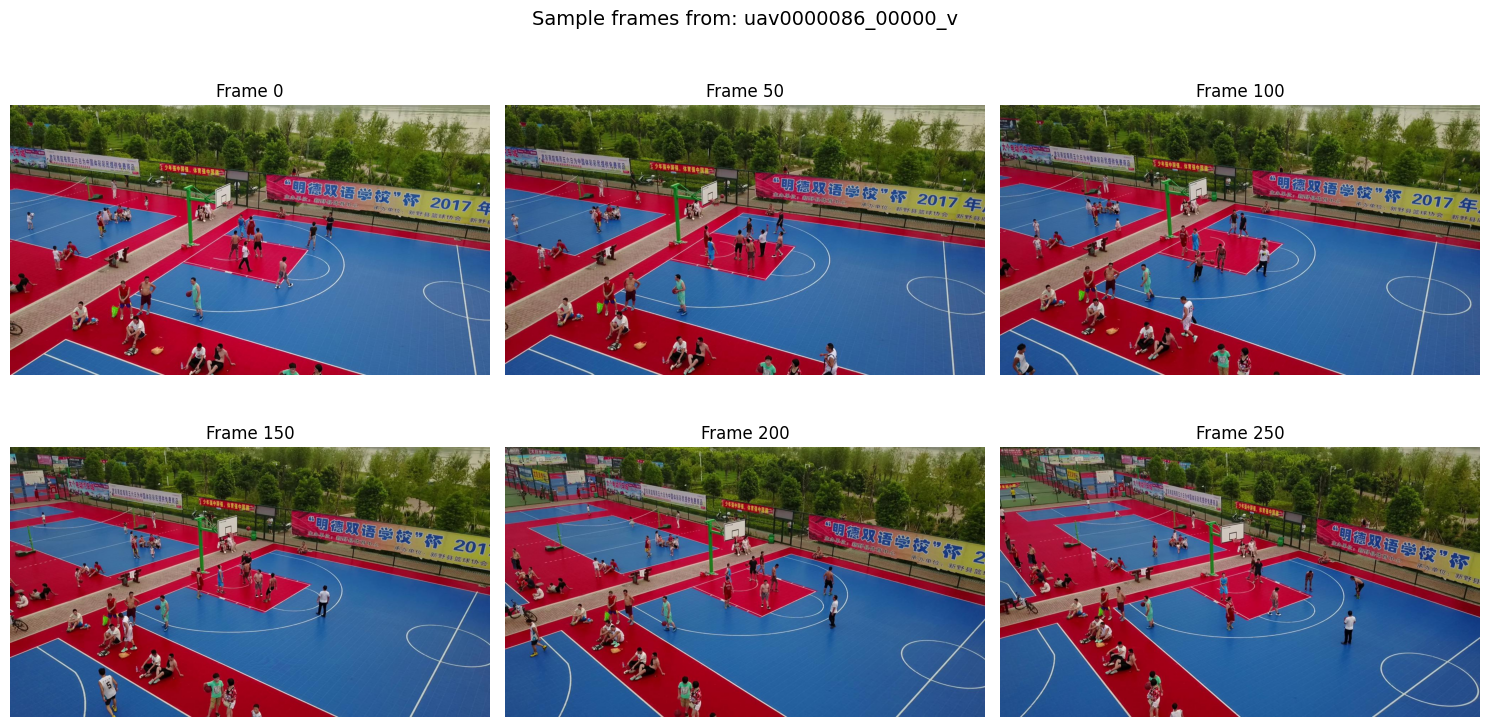

Saved to results/sample_frames.png


In [9]:
# Pick first sequence
seq = sequences[0]
frames = sorted(seq.glob("*.jpg"))

# Show 6 sample frames
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sample frames from: {seq.name}", fontsize=14)

sample_indices = [0, 50, 100, 150, 200, 250]
for ax, idx in zip(axes.flatten(), sample_indices):
    if idx < len(frames):
        img = cv2.imread(str(frames[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"Frame {idx}")
        ax.axis('off')

plt.tight_layout()
plt.savefig("../results/sample_frames.png")
plt.show()
print("Saved to results/sample_frames.png")

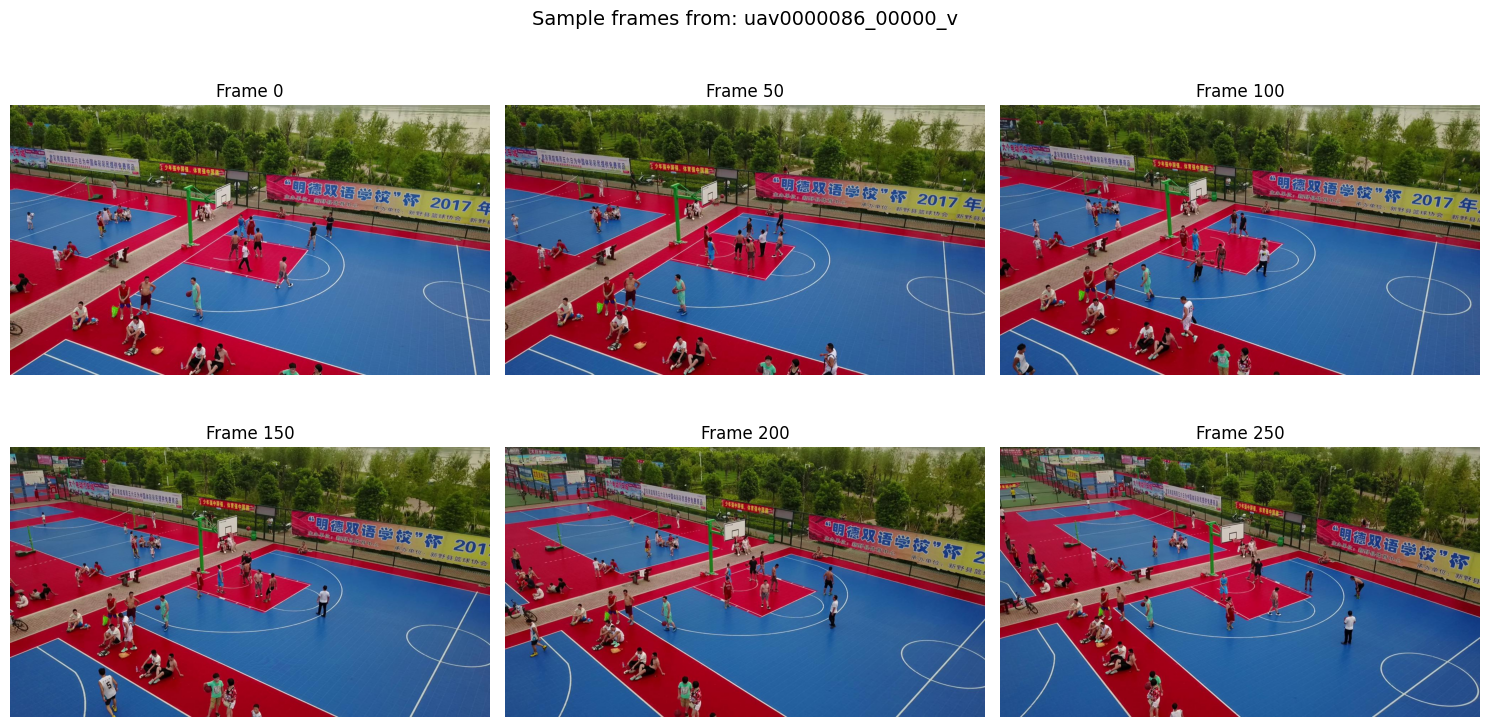

Saved to results/sample_frames.png


In [10]:
# Pick first sequence
seq = sequences[0]
frames = sorted(seq.glob("*.jpg"))

# Show 6 sample frames
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sample frames from: {seq.name}", fontsize=14)

sample_indices = [0, 50, 100, 150, 200, 250]
for ax, idx in zip(axes.flatten(), sample_indices):
    if idx < len(frames):
        img = cv2.imread(str(frames[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"Frame {idx}")
        ax.axis('off')

plt.tight_layout()
plt.savefig("../results/sample_frames.png")
plt.show()
print("Saved to results/sample_frames.png")

In [11]:
sample_img = cv2.imread(str(frames[0]))
h, w, c = sample_img.shape
print(f"Image dimensions: {w} x {h} pixels")
print(f"Channels: {c}")

Image dimensions: 1344 x 756 pixels
Channels: 3


In [12]:
anno_path = Path("../data/VisDrone2019-MOT-val/annotations")
anno_files = sorted(anno_path.glob("*.txt"))

print(f"Annotation files: {len(anno_files)}")

# Read first annotation file
with open(anno_files[0], 'r') as f:
    lines = f.readlines()

print(f"\nFirst annotation file: {anno_files[0].name}")
print(f"Total annotations: {len(lines)}")
print(f"\nSample line: {lines[0].strip()}")
print("\nFormat: frame_id, target_id, x, y, w, h, score, category, truncation, occlusion")

Annotation files: 7

First annotation file: uav0000086_00000_v.txt
Total annotations: 23877

Sample line: 102,0,38,666,71,88,1,1,1,0

Format: frame_id, target_id, x, y, w, h, score, category, truncation, occlusion


In [13]:
all_widths = []
all_heights = []
person_count = 0

with open(anno_files[0], 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) >= 8:
            category = int(parts[7])
            if category in [1, 2]:  # pedestrian or people
                w = int(parts[4])
                h = int(parts[5])
                all_widths.append(w)
                all_heights.append(h)
                person_count += 1

print(f"Total person annotations: {person_count}")
print(f"\nBounding box sizes:")
print(f"  Average width:  {np.mean(all_widths):.1f} px")
print(f"  Average height: {np.mean(all_heights):.1f} px")
print(f"  Min width:  {min(all_widths)} px")
print(f"  Min height: {min(all_heights)} px")
print(f"  Max width:  {max(all_widths)} px")
print(f"  Max height: {max(all_heights)} px")

Total person annotations: 22098

Bounding box sizes:
  Average width:  32.7 px
  Average height: 60.3 px
  Min width:  11 px
  Min height: 14 px
  Max width:  101 px
  Max height: 144 px


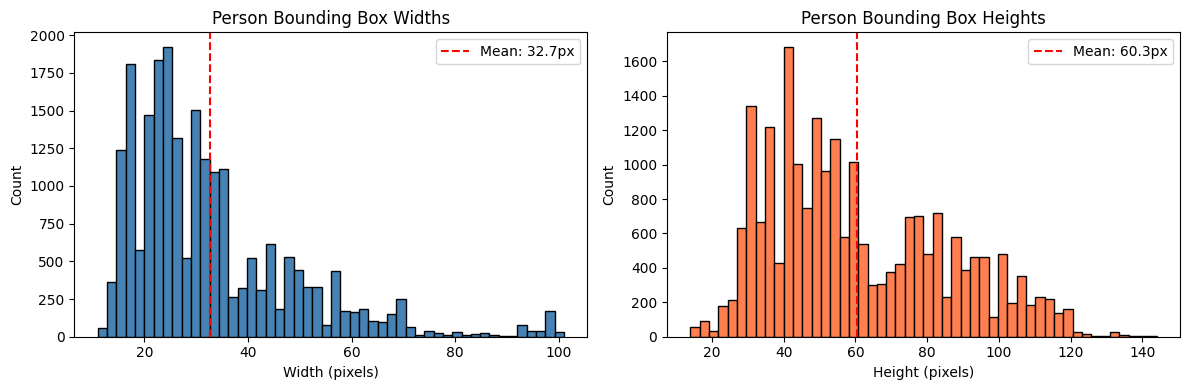

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(all_widths, bins=50, color='steelblue', edgecolor='black')
ax1.set_title("Person Bounding Box Widths")
ax1.set_xlabel("Width (pixels)")
ax1.set_ylabel("Count")
ax1.axvline(np.mean(all_widths), color='red', 
            linestyle='--', label=f'Mean: {np.mean(all_widths):.1f}px')
ax1.legend()

ax2.hist(all_heights, bins=50, color='coral', edgecolor='black')
ax2.set_title("Person Bounding Box Heights")
ax2.set_xlabel("Height (pixels)")
ax2.set_ylabel("Count")
ax2.axvline(np.mean(all_heights), color='red',
            linestyle='--', label=f'Mean: {np.mean(all_heights):.1f}px')
ax2.legend()

plt.tight_layout()
plt.savefig("../results/bbox_size_distribution.png")
plt.show()

Code  ▼

In [16]:
## Key Observations

1. **Small target problem:** Most persons appear between 10-40 pixels tall.
   Standard object detectors are trained on larger objects, so this is
   the core challenge of this assignment.

2. **Camera motion:** The drone is moving, so the background shifts every
   frame. This causes ID switching in trackers that rely on fixed positions.

3. **Crowding:** Multiple persons often appear close together, causing
   overlap and occlusion.

## My Plan Based on This Analysis
- Use SAHI (tiled inference) to improve small person detection
- Use ByteTrack which uses motion prediction to handle ID switching
- Tune confidence threshold lower (0.25) to catch more small persons

SyntaxError: invalid syntax (2419368942.py, line 3)